# Notebook 03 — Feature Engineering

This notebook collapses the player match table into one row per player, with the
churn label and the behavioral features used for the analysis. The feature period
is split at its global midpoint into a first and second half, so engagement and
performance trends can be measured. The result is `player_features.csv`.

## Feature groups

- **Engagement.** total games, games trend (second half minus first half), games per
  active day, and days since the last game before the window closed.
- **Performance and trajectory.** win rate and its trend, average KDA, net wins.
- **Variety and role.** unique champions, top champion share, role focus, primary role.
- **Tenure and session.** account level, night share.
- **Frustration and contribution.** time spent dead, whether the player led their team
  or the game in deaths, kill participation, team damage share, frustration pings,
  surrender losses, and average loss duration.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("..")/"data"
NAVY, GOLD, RED = "#1A3A5C", "#C9A14A", "#C62828"
pd.set_option("display.max_columns", None)

m = pd.read_csv(DATA/"player_match.csv")
m["game_start"] = pd.to_datetime(m["game_start"], format="ISO8601", utc=True)
m["churned"] = m["churned"].astype(int)
m = m.sort_values(["puuid","game_start"])
print(f"{len(m):,} player-match rows, {m.puuid.nunique()} players")

105,637 player-match rows, 704 players


In [2]:
TIER_BANDS = {"IRON":"low","BRONZE":"low","SILVER":"low","GOLD":"mid","PLATINUM":"mid",
              "EMERALD":"mid","DIAMOND":"high","MASTER":"high","GRANDMASTER":"high","CHALLENGER":"high"}
NIGHT = set(range(0,7))
wstart, wend = m.game_start.min(), m.game_start.max()
midpoint = wstart + (wend - wstart)/2

def loss_streak(wins):
    longest = cur = 0
    for x in wins:
        if x == 0: cur += 1; longest = max(longest, cur)
        else: cur = 0
    return longest

rows = []
for pid, g in m.groupby("puuid"):
    g = g.sort_values("game_start"); n = len(g)
    fh, sh = g[g.game_start < midpoint], g[g.game_start >= midpoint]
    losses = g[g.win == 0]
    days = pd.to_datetime(g.game_date).drop_duplicates().sort_values()
    rows.append({
        "puuid": pid, "tier": g.tier.iloc[0], "tier_band": TIER_BANDS.get(g.tier.iloc[0], "mid"),
        "churned": int(g.churned.iloc[0]),
        "total_games": n, "games_trend": len(sh) - len(fh),
        "games_per_active_day": round(n/days.nunique(), 2),
        "net_wins": int(g.win.sum() - (n - g.win.sum())),
        "days_since_last": int((pd.to_datetime(wend.date()) - days.max()).days),
        "win_rate": round(g.win.mean(), 4),
        "win_rate_trend": round(sh.win.mean() - fh.win.mean(), 4) if len(fh) and len(sh) else 0,
        "avg_kda": round(g.kda.mean(), 3), "avg_duration_min": round(g.duration_sec.mean()/60, 2),
        "longest_loss_streak": loss_streak(g.win.tolist()),
        "unique_champions": g.champion.nunique(), "top_champion_share": round(g.champion.value_counts().iloc[0]/n, 3),
        "role_focus": round(g.position.value_counts().iloc[0]/n, 3), "primary_role": g.position.mode().iloc[0],
        "night_share": round(g.game_hour_utc.isin(NIGHT).mean(), 3), "account_level": int(g.account_level.max()),
        "time_dead_share": round((g.time_dead_sec/g.duration_sec).mean(), 4),
        "team_death_leader_share": round(g.team_death_leader.mean(), 4),
        "game_death_leader_share": round(g.game_death_leader.mean(), 4),
        "avg_kill_participation": round(g.kill_participation.mean(), 4),
        "avg_team_damage_share": round(g.team_damage_share.mean(), 4),
        "avg_multikills": round(g.multikills.mean(), 3),
        "avg_frustration_pings": round(g.frustration_pings.mean(), 3),
        "first_blood_rate": round(g.first_blood.mean(), 4),
        "surrender_loss_share": round(((g.win==0)&(g.surrender==1)).mean(), 4),
        "avg_loss_duration_min": round(losses.duration_sec.mean()/60, 2) if len(losses) else 0,
    })
features = pd.DataFrame(rows)
features.to_csv(DATA/"player_features.csv", index=False)
print(f"{len(features)} players, {features.shape[1]} columns. Churned: {int(features.churned.sum())}")

704 players, 30 columns. Churned: 67


In [3]:
features.head()

,puuid,tier,tier_band,churned,total_games,games_trend,games_per_active_day,net_wins,days_since_last,win_rate,win_rate_trend,avg_kda,avg_duration_min,longest_loss_streak,unique_champions,top_champion_share,role_focus,primary_role,night_share,account_level,time_dead_share,team_death_leader_share,game_death_leader_share,avg_kill_participation,avg_team_damage_share,avg_multikills,avg_frustration_pings,first_blood_rate,surrender_loss_share,avg_loss_duration_min
0,-0jUMx2qQvZ1IAx60gOz__nlynUyHanjCT9ZrgZPgv7lGN...,GRANDMASTER,high,0,107,-21,3.06,9,17,0.5421,-0.2842,4.557,28.37,8,20,0.280,0.561,JUNGLE,0.000,489,0.0878,0.2150,0.1028,0.5626,0.1897,0.841,12.075,0.0654,0.1308,28.40
1,-24JAEu70lmkkX8Qy_Ny4MHg4bpJdwGGH89CXFukOpH_gr...,SILVER,low,0,64,-10,2.37,-10,10,0.4219,-0.1532,2.222,31.49,7,25,0.172,0.531,JUNGLE,0.031,745,0.1325,0.5312,0.3281,0.4112,0.1684,0.516,8.438,0.0469,0.0312,32.18
2,-CeOkEwxJTm2QDCMIwaOQQskaP9wlC1GZURm8mb-OG_sqQ...,PLATINUM,mid,1,196,180,5.60,10,21,0.5255,-0.2340,3.378,30.95,8,32,0.143,0.847,MIDDLE,0.255,733,0.1144,0.2398,0.1122,0.4011,0.2046,0.643,10.582,0.1173,0.0612,31.71
3,-VV2Sjh__oX37TGsa61RJ40AdtbSRfmxpHtvXbCO0VWHlV...,GOLD,mid,0,42,42,2.21,2,17,0.5238,0.0000,2.984,29.64,3,14,0.214,0.952,BOTTOM,0.048,553,0.1148,0.3333,0.1429,0.4421,0.2106,0.952,7.571,0.1190,0.2143,29.36
4,-dEjhcszO9SKrKHaAU8KrzC0-VOUaRxzKdUP4-DaeH6DUW...,GRANDMASTER,high,0,107,107,4.86,15,1,0.5701,0.0000,4.639,27.25,6,11,0.748,0.841,JUNGLE,0.196,817,0.1042,0.2336,0.0748,0.5796,0.2299,0.832,18.981,0.0935,0.0748,29.04


## Which features separate churned from retained

Churn lives in the low and mid tiers, so we measure the effect size (Cohen's d) of
each feature there. Positive means higher in churners, negative means lower.

In [4]:
sub = features[features.tier_band.isin(["low","mid"])]
c_, r_ = sub[sub.churned==1], sub[sub.churned==0]
def cohens_d(a, b):
    sp = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2)/(len(a)+len(b)-2))
    return (a.mean()-b.mean())/sp if sp else 0
cols = [x for x in features.columns if x not in ["puuid","tier","tier_band","churned","primary_role"]]
eff = pd.DataFrame({"cohens_d":[cohens_d(c_[x], r_[x]) for x in cols]}, index=cols)
eff = eff.reindex(eff.cohens_d.abs().sort_values(ascending=False).index)
print(f"low+mid: {len(sub)} players, {int(sub.churned.sum())} churned ({100*sub.churned.mean():.0f}%)\n")
eff.round(3)

low+mid: 335 players, 67 churned (20%)



,cohens_d
days_since_last,1.032
games_per_active_day,0.454
avg_kda,0.445
unique_champions,-0.412
time_dead_share,-0.409
avg_duration_min,-0.395
role_focus,0.381
games_trend,-0.340
avg_loss_duration_min,-0.332
top_champion_share,0.306


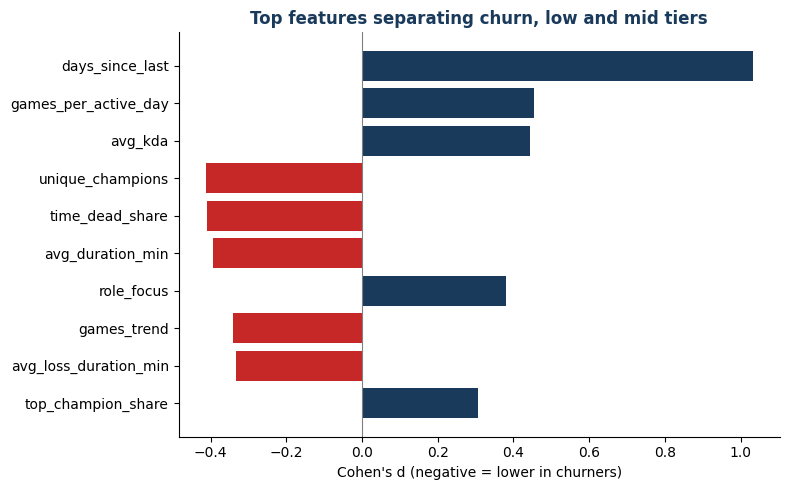

In [5]:
top = eff.head(10).iloc[::-1]
colors = [RED if v < 0 else NAVY for v in top.cohens_d]
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top.index, top.cohens_d, color=colors); ax.axvline(0, color="grey", lw=.8)
ax.set_xlabel("Cohen's d (negative = lower in churners)")
ax.set_title("Top features separating churn, low and mid tiers", color=NAVY, fontweight="bold")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

**Read.** The strongest signal by far is **days since the last game**, churners had
already tapered off weeks before the window closed. After that the picture is
disengagement, not frustration. Churners play in concentrated bursts, lean on fewer
champions and one role, and their engagement trend is flat. Notably the frustration
hypotheses do not hold, churners spend **less** time dead, are **less** often the
team's death leader, and their raw win rate is fine. They are competent, narrow,
bursty players who quietly disengage.

**Next:** `04_churn_analysis.ipynb` quantifies these drivers with a model and lays out
the business read.